# Big Plot

Read `Processed_data/cleaned_iv_data/all_cleaned_iv.csv` and make:
1. `V-I` with temperature colorbar
2. `log(V)-log(I)` with temperature colorbar
3. `R-T` with current colorbar


In [21]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25


In [22]:
def find_project_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()
    for p in [start, *start.parents]:
        if (p / 'Processed_data').exists():
            return p
    raise FileNotFoundError('Cannot find project root containing Processed_data/.')


def pick_col(columns, candidates):
    lower = {str(c).lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None


def parse_temp_to_k(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce')
    txt = series.astype(str)
    out = txt.str.extract(r'([+-]?\d+(?:\.\d+)?)', expand=False)
    return pd.to_numeric(out, errors='coerce')


PROJECT_ROOT = find_project_root()
CSV_PATH = PROJECT_ROOT / 'Processed_data' / 'analysis_inputs' / 'all_cleaned_iv.csv'

df = pd.read_csv(CSV_PATH)

col_I = pick_col(df.columns, ['I', 'I_A', 'current'])
col_V = pick_col(df.columns, ['V', 'V_V', 'voltage'])
col_R = pick_col(df.columns, ['R', 'R_Ohm', 'resistance'])
col_T = pick_col(df.columns, ['temp', 'T', 'T_K', 'temperature'])

if col_I is None or col_V is None or col_T is None:
    raise ValueError(f'Need I/V/temp columns. Current columns: {list(df.columns)}')

plot_df = pd.DataFrame({
    'I': pd.to_numeric(df[col_I], errors='coerce'),
    'V': pd.to_numeric(df[col_V], errors='coerce'),
    'T_K': parse_temp_to_k(df[col_T]),
})

if 'sweep_part' in df.columns:
    plot_df['sweep_part'] = df['sweep_part'].astype(str).fillna('unknown')
else:
    plot_df['sweep_part'] = 'unknown'

if col_R is not None:
    plot_df['R'] = pd.to_numeric(df[col_R], errors='coerce')
else:
    plot_df['R'] = plot_df['V'] / plot_df['I'].replace(0, np.nan)

# If monotonic_keep exists, keep only True rows.
if 'monotonic_keep' in df.columns:
    keep = df['monotonic_keep'].fillna(False).astype(bool)
    plot_df = plot_df.loc[keep].copy()

plot_df = plot_df.dropna(subset=['I', 'V', 'T_K', 'R']).reset_index(drop=True)

print('CSV:', CSV_PATH)
print('Rows for plotting:', len(plot_df))
print('Temperature range (K):', float(plot_df['T_K'].min()), '~', float(plot_df['T_K'].max()))


CSV: /Users/pirin/Desktop/Lab_summer_research_BSCCO_device/Processed_data/analysis_inputs/all_cleaned_iv.csv
Rows for plotting: 17946
Temperature range (K): 2.0 ~ 110.0


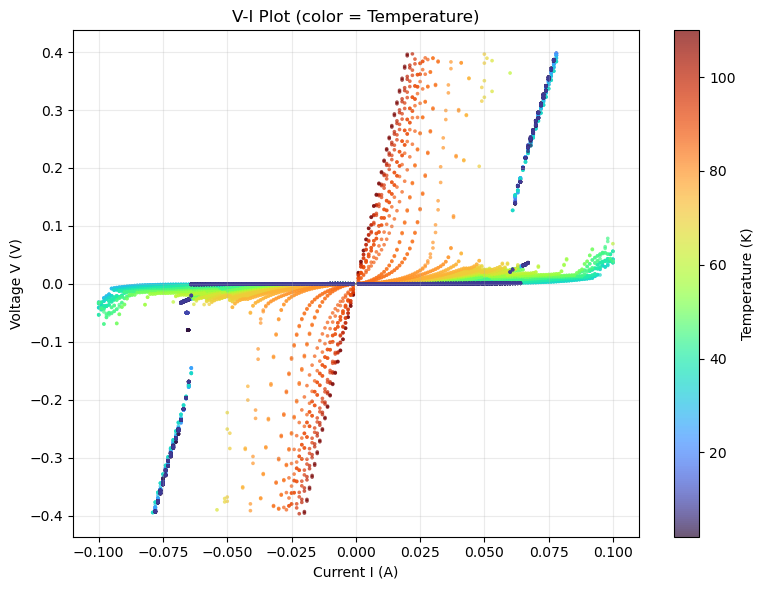

In [23]:
# 1) V-I with temperature colorbar
fig, ax = plt.subplots()
sc = ax.scatter(
    plot_df['I'],
    plot_df['V'],
    c=plot_df['T_K'],
    cmap='turbo',
    s=7,
    alpha=0.7,
    linewidths=0,
)
ax.set_xlabel('Current I (A)')
ax.set_ylabel('Voltage V (V)')
ax.set_title('V-I Plot (color = Temperature)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Temperature (K)')
plt.tight_layout()
plt.show()


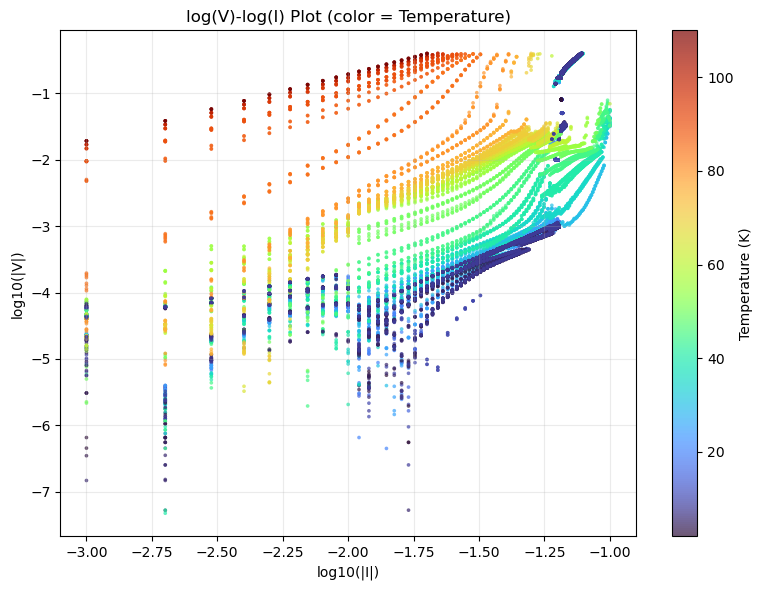

In [24]:
# 2) log(V)-log(I) with temperature colorbar
# Use absolute values and keep only strictly positive points for log-scale.
log_df = plot_df[(plot_df['I'].abs() > 0) & (plot_df['V'].abs() > 0)].copy()

x = np.log10(log_df['I'].abs())
y = np.log10(log_df['V'].abs())

fig, ax = plt.subplots()
sc = ax.scatter(
    x,
    y,
    c=log_df['T_K'],
    cmap='turbo',
    s=7,
    alpha=0.7,
    linewidths=0,
)
ax.set_xlabel('log10(|I|)')
ax.get_xlim 
ax.set_ylabel('log10(|V|)')
ax.set_title('log(V)-log(I) Plot (color = Temperature)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Temperature (K)')
plt.tight_layout()
plt.show()


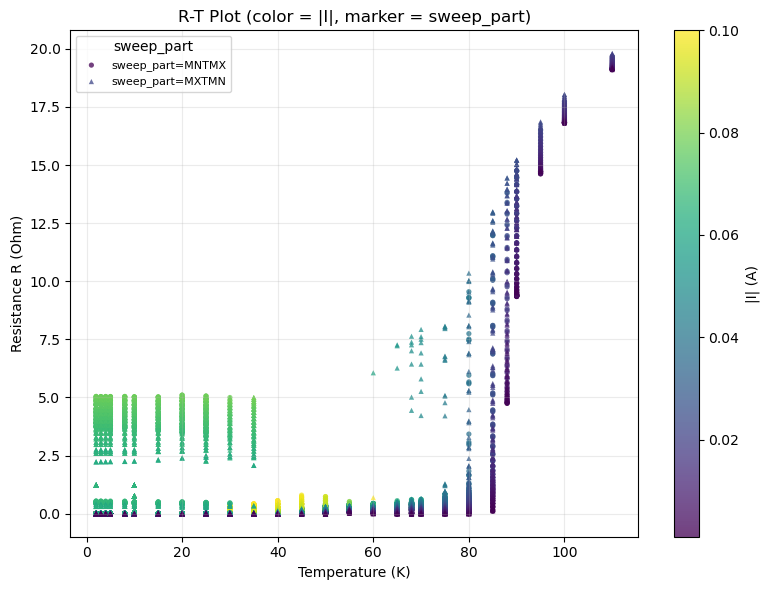

In [25]:
# 3) R-T with abs(I) colorbar + sweep_part marker encoding
fig, ax = plt.subplots()

parts = sorted(plot_df['sweep_part'].dropna().unique().tolist())
if not parts:
    parts = ['unknown']

markers = ['o', '^', 's', 'D', 'P', 'X']
abs_i = plot_df['I'].abs()
vmin = float(abs_i.min())
vmax = float(abs_i.max())

first_scatter = None
for idx, part in enumerate(parts):
    mask = plot_df['sweep_part'] == part
    if mask.sum() == 0:
        continue

    sc = ax.scatter(
        plot_df.loc[mask, 'T_K'],
        plot_df.loc[mask, 'R'],
        c=plot_df.loc[mask, 'I'].abs(),
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        s=14,
        alpha=0.75,
        linewidths=0,
        marker=markers[idx % len(markers)],
        label=f'sweep_part={part}',
    )
    if first_scatter is None:
        first_scatter = sc

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Resistance R (Ohm)')
ax.set_title('R-T Plot (color = |I|, marker = sweep_part)')

if first_scatter is not None:
    cbar = plt.colorbar(first_scatter, ax=ax)
    cbar.set_label('|I| (A)')

ax.legend(title='sweep_part', loc='best', fontsize=8)
plt.tight_layout()
plt.show()
